# Uinta Mountain Group ca. 754 Ma paleomagnetic pole

## Geologic context

The Uinta Mountain Group is a thick (4–7 km) succession of Tonian
(Neoproterozoic) quartzose to
arkosic sandstone and interbedded mudstone exposed
in the east–west Laramide Uinta uplift of northeast Utah, northwest Colorado, and
southwest Wyoming (Weil, Geissman & Ashby, 2006). It is interpreted to have accumulated in an
east–west-trending intracratonic rift basin and is one of the three **ChUMP**
(Chuar–Uinta Mountains–Pahrump) successions of southwestern Laurentia — regional
correlatives interpreted to record rift-basin evolution beginning ca. 770 Ma
during the incipient rifting of western Laurentia from Rodinia (Dehler et al.,
2023).

## Chronostratigraphy (Dehler et al., 2023)

Dehler et al. (2023) refined the Uinta Mountain Group depositional age with U-Pb chemical
abrasion–isotope dilution–thermal ionization mass spectrometry (CA-ID-TIMS) on
detrital zircon. The Uinta Mountain Group yields a maximum depositional age (MDA) of
766.3 ± 0.5 Ma (n = 5), with a second young detrital mode at 775.1 ± 0.7 Ma
(n = 3). Critically, the 766.3 Ma grains occur ~60 m above the base of the eastern
UMG (basal Jesse Ewing Canyon Formation), which requires that the **entire UMG is
younger than 766 Ma** — a refinement of earlier SHRIMP/LA-ICP-MS
maximum ages (e.g. 766.4 ± 4.8 Ma from the Outlaw Trail formation; Dehler et al.,
2010). The ca. 775–770 Ma detrital populations are interpreted to derive from the
770–778 Ma Gunbarrel Large Igneous Province, and the 766 Ma population from the
Mt Rogers complex of eastern Laurentia or from conjugate margins (e.g. Tasmania).

Based on correlation the Red Pine Formation of the Uinta Mountain Group with the upper Chuar Group (which both have vase-shape microfossils), the upper Uinta Mountain Group is considered to be ca. 730 Ma. As a result the old age bound is 766.3 ± 0.5 Ma and the younger age bound is 730 Ma.

of vase-shaped mi
These dates anchor  that places ChUMP deposition in the
late Tonian, ca. 770–740 Ma — bracketing the ca. 754 Ma paleomagnetic pole
reported here within the post-766 Ma UMG.

## Pole

This notebook recreates the UMG characteristic-remanence pole at the site level
from the 9 sampling localities (79 sites) of Weil et al. (2006). The primary ChRM
is a west- or east-directed (dual-polarity), shallow, hematite-carried
magnetization; the four eastern localities that yielded only a north-directed
present-field viscous overprint are shown separately.

In [1]:
import pole_tools as pt
import pmagpy.ipmag as ipmag
import pmagpy.pmag as pmag
import pandas as pd
import matplotlib.pyplot as plt

%config InlineBackend.figure_format='retina'
%matplotlib inline

## Locality poles and the UMG mean

The locations table holds a VGP (locality pole) for each sampling locality. The
UMG pole is the Fisher mean of the 9 primary-ChRM locality VGPs; the four
present-field overprint localities (Irish Canyon, Cross Mountain, Lone Mountain,
Juniper Mountain) are excluded.

9 primary localities
Plon: 161.3  Plat: 0.8
Number of directions in mean (n): 9
Angular radius of 95% confidence (A_95): 4.6
Precision parameter (k) estimate: 125.6

Weil et al. (2006) UMG pole: 0.8 N / 161.3 E, A95 4.6, N=9


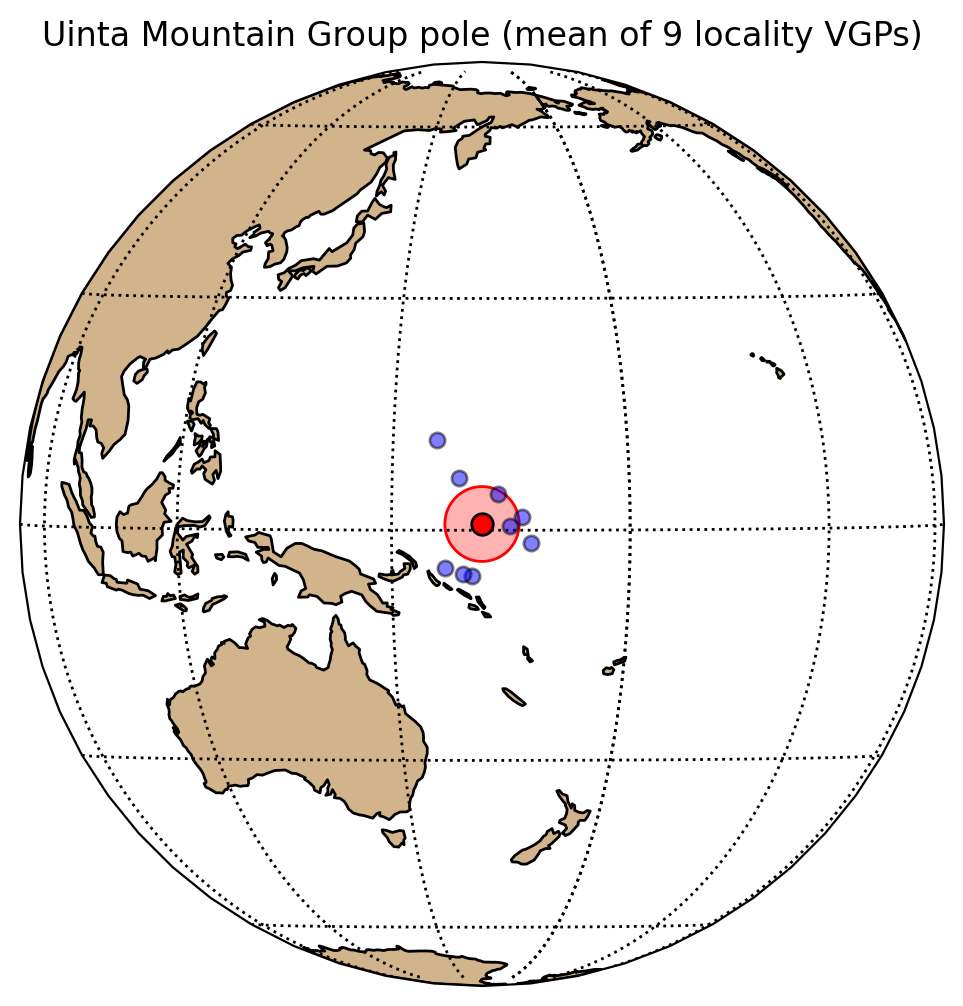

In [2]:
locs = pd.read_csv('../data/754_Uinta_Mountain_Group/locations.txt', sep='\t', skiprows=1)
overprint = ['Irish Canyon Section', 'Cross Mountain', 'Lone Mountain', 'Juniper Mountain']
primary = locs[(~locs['location'].isin(overprint)) &
               (~locs['location'].str.contains('Uinta Mountain Group ca', na=False))].copy()
study_lat, study_lon = 40.8, 250.7

# treat each locality VGP as one site for the grand-mean pole
loc_sites = pd.DataFrame({'site': primary['location'], 'vgp_lat': primary['pole_lat'],
                          'vgp_lon': primary['pole_lon'], 'dir_tilt_correction': 100,
                          'dir_n_samples': primary['pole_n_sites'].fillna(1).astype(int)})
print(f'{len(loc_sites)} primary localities')
vgp_block, pole_mean = pt.compute_mean_pole(loc_sites, unify_polarity=True)
ipmag.print_pole_mean(pole_mean)
print('\nWeil et al. (2006) UMG pole: 0.8 N / 161.3 E, A95 4.6, N=9')
_ = pt.plot_vgps_and_pole(vgp_block, pole_mean, central_longitude=pole_mean['dec'],
                          central_latitude=pole_mean['inc'], figsize=(6, 6))
plt.title('Uinta Mountain Group pole (mean of 9 locality VGPs)')
plt.show()

## Present-field overprint localities (context)

The four eastern localities carry a north-directed, steep, present-field viscous
remanence — their VGPs plot near the present pole, not with the UMG ChRM.

In [3]:
op = locs[locs['location'].isin(overprint)]
print(op[['location', 'pole_lat', 'pole_lon', 'pole_alpha95', 'pole_n_sites']].to_string(index=False))

            location  pole_lat  pole_lon  pole_alpha95  pole_n_sites
Irish Canyon Section      79.7     322.2           5.6            22
      Cross Mountain      83.9     177.8           6.9            22
       Lone Mountain      88.2     203.6           7.0            22
    Juniper Mountain      88.2     203.6          12.9            64


## Paleosecular variation

The dual-polarity ChRM (west-normal / east-reverse) and the spread of locality
VGPs indicate the magnetization averaged secular variation; the Deenen et al.
(2011) test is applied to the 9-locality mean.

A_95 of 4.6 is too small for Deenen criteria of 5.0 for this number of sites


<AxesSubplot:title={'center':'Deenen et al. (2011) test'}, xlabel='Number of sites (N)', ylabel='$A_{95}$ (°)'>

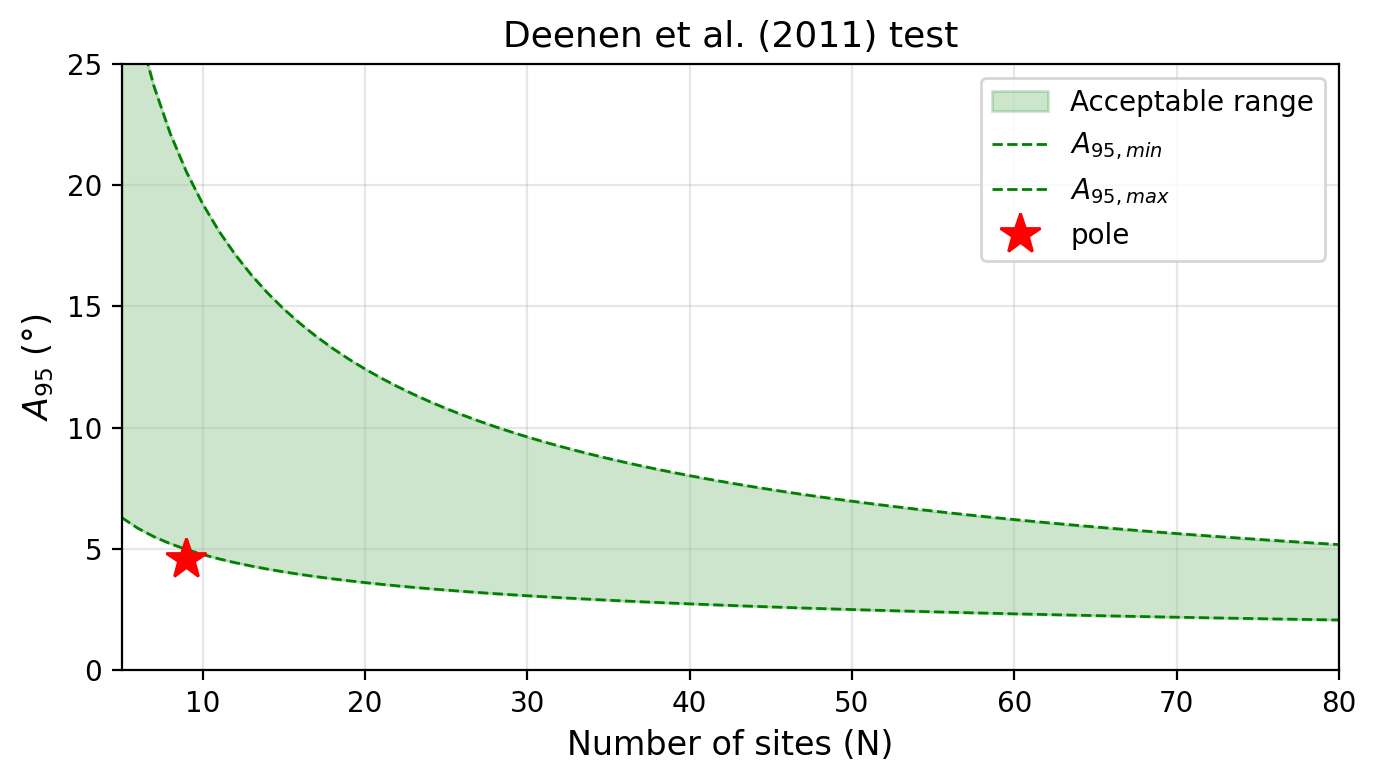

In [4]:
pt.Deenen_test(pole_mean['n'], pole_mean['alpha95'])
pt.plot_Deenen_test(pole_mean)

## The UMG pole in the context of the Laurentia APWP

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


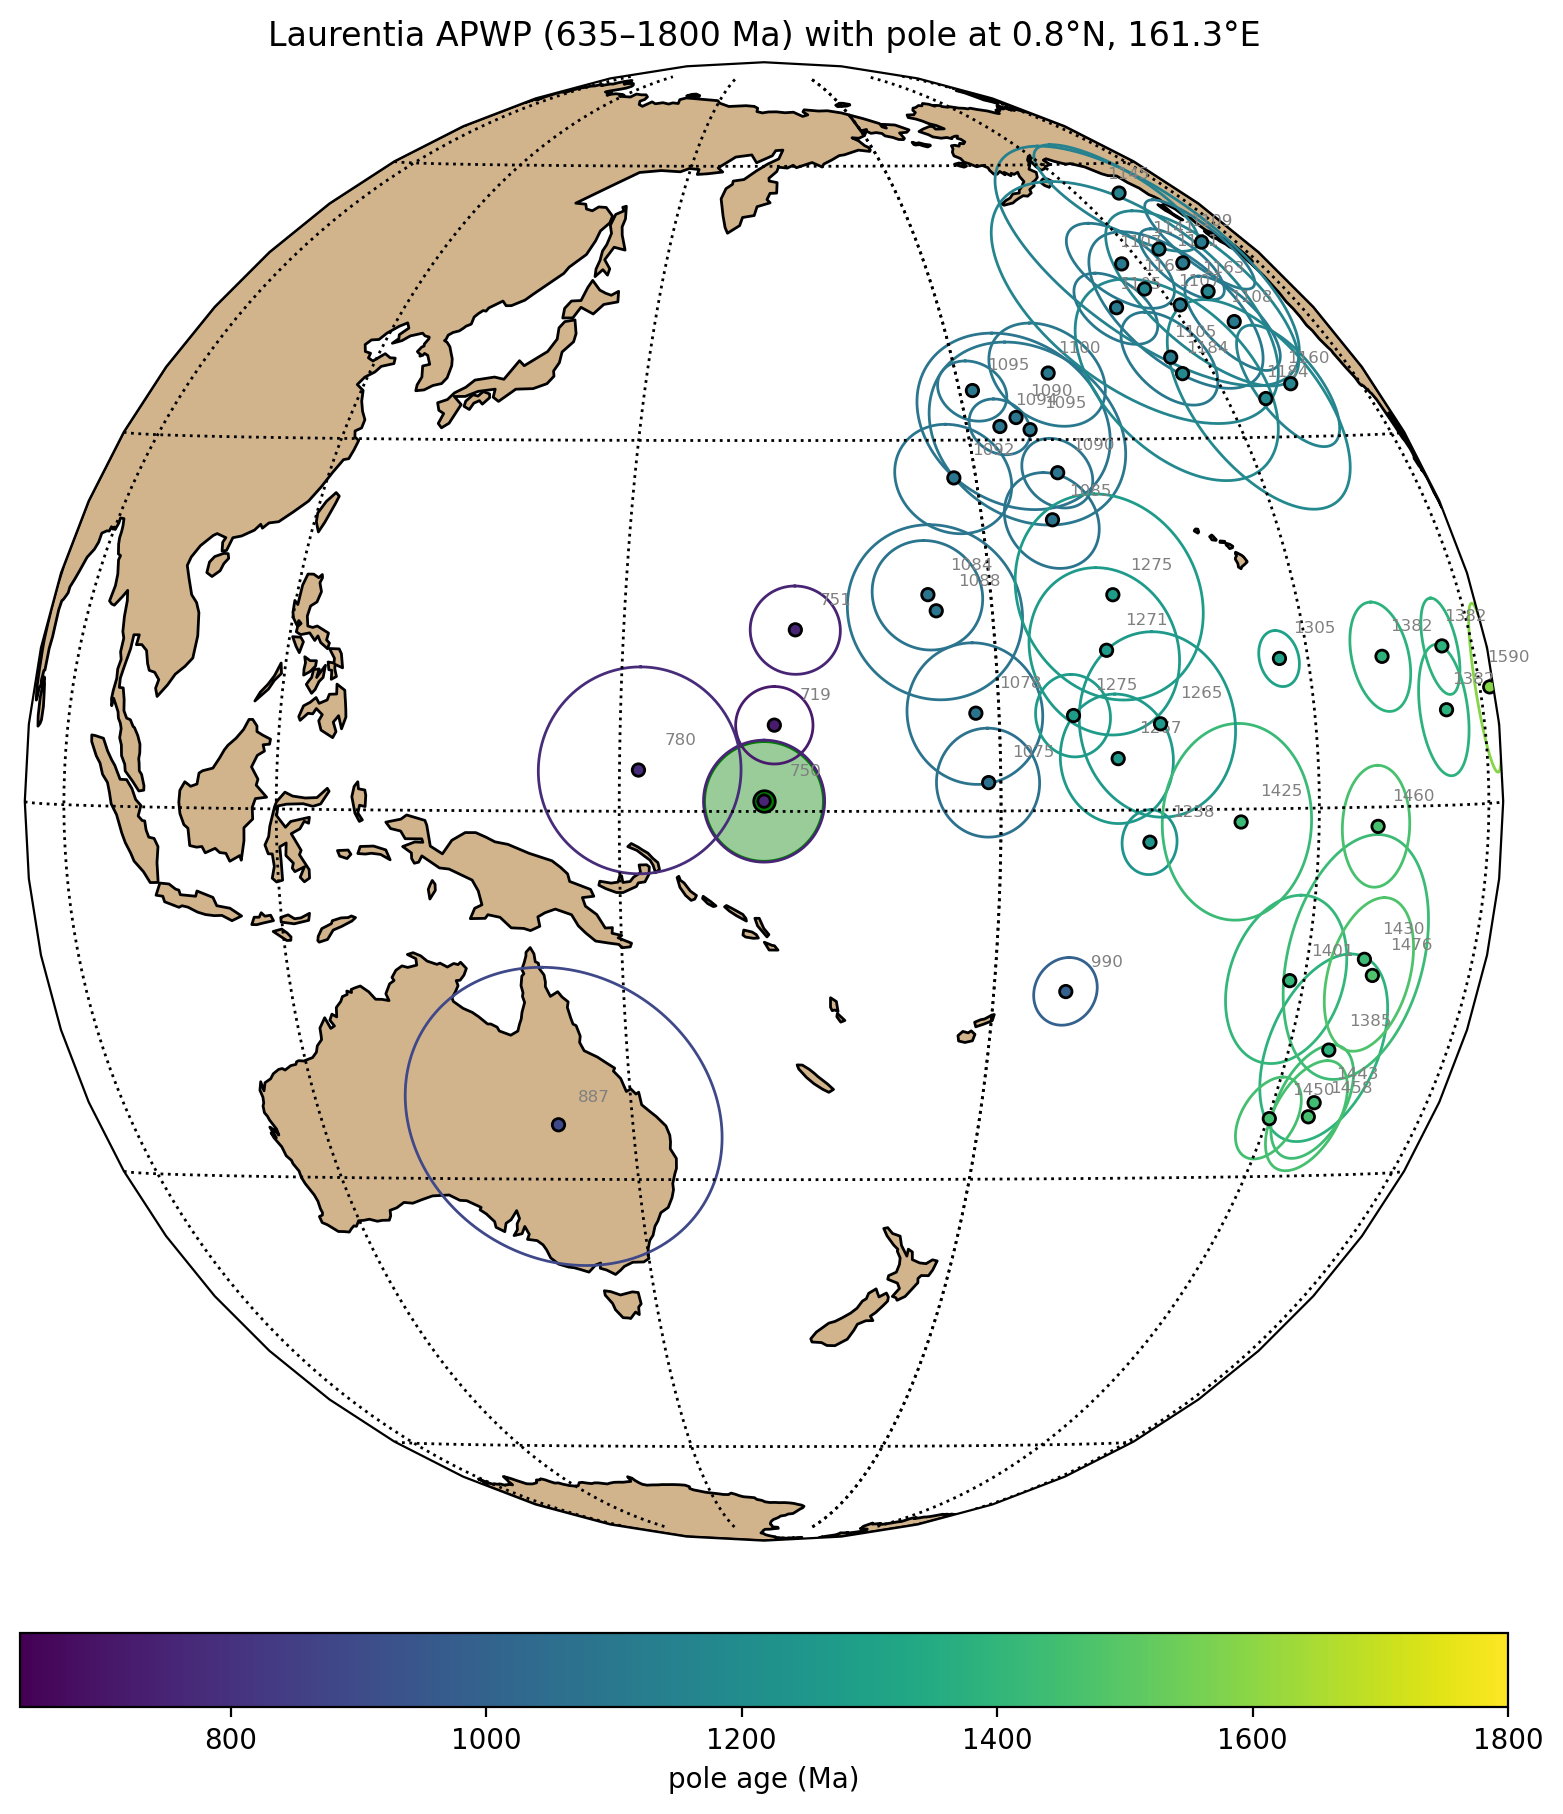

In [5]:
Laurentia_poles = pt.get_Laurentia_poles()
ax = pt.plot_apwp_context(Laurentia_poles, pole_mean['inc'], pole_mean['dec'],
                          pole_mean['alpha95'], age_min=635, age_max=1800,
                          projection='orthographic',
                          central_longitude=pole_mean['dec'],
                          central_latitude=pole_mean['inc'])
plt.show()

## R7: comparison with younger Laurentia poles

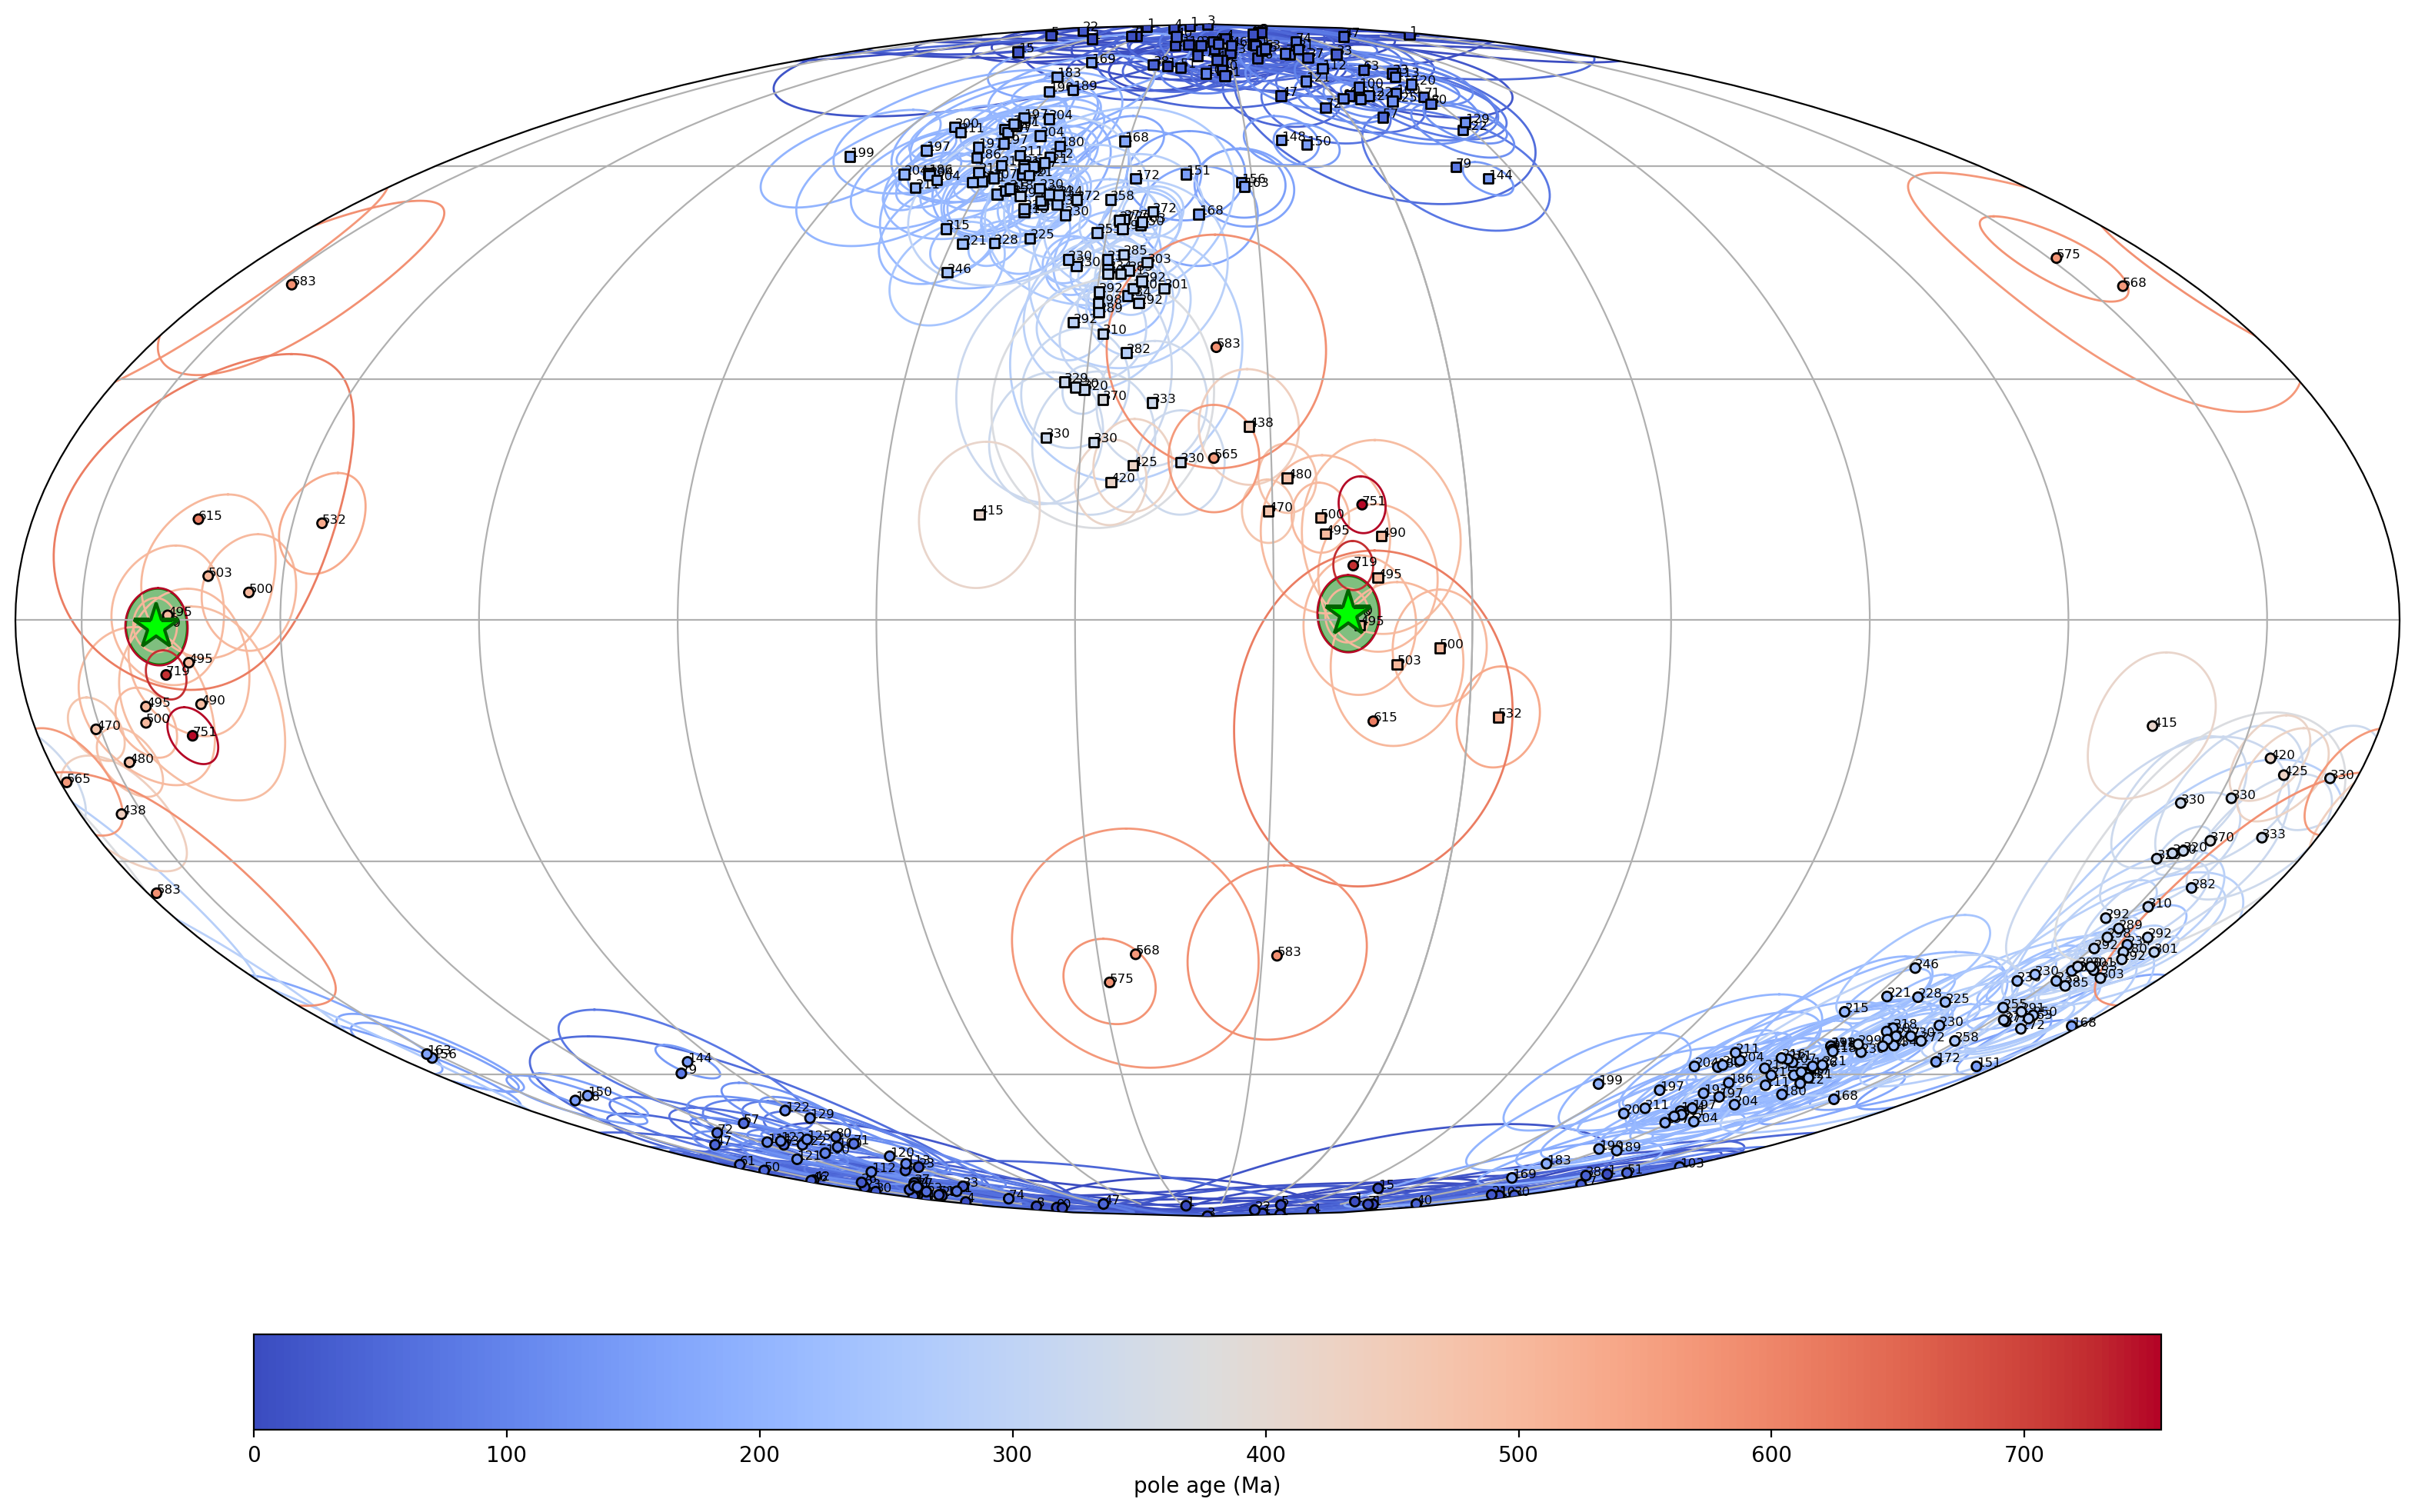

<GeoAxesSubplot:>

In [6]:
Laurentia_stricto_poles = pt.get_Laurentia_stricto_poles()
pt.plot_pole_overlap('Uinta Mountain Group', Laurentia_stricto_poles,
                     pt.Torsvik2012_Laurentia,
                     pole_plat=pole_mean['inc'], pole_plon=pole_mean['dec'],
                     pole_A95=pole_mean['alpha95'], pole_age=754)

## R-score summary (Meert et al., 2020)

| R | Criterion | Score | Justification |
|---|---|---|---|
| 1 | Age within ± 15 Ma | **0** | A maximum-depositional-age bracket: CA-ID-TIMS detrital zircon places the entire UMG younger than 766 Ma (MDA 766.3 ± 0.5 Ma; Dehler et al., 2023), but no dated horizon ties the pole's stratigraphic level to ± 15 Ma. |
| 2 | Techniques and statistical analysis | **1** | Thermal + chemical demagnetization, PCA, IRM mineralogy; N = 9 localities (79 sites); the dual-polarity ChRM averages secular variation. |
| 3 | Magnetic mineralogy characterized | **1** | Remanence carried by hematite, characterized by high unblocking temperatures (660-680 °C) and three-axis IRM (Weil et al., 2006). |
| 4 | Field tests constrain age of magnetization | **0** | Fold tests were local/inconclusive; no decisive regional field test. |
| 5 | Structural control / tectonic coherence | **0** | Detrital hematite sedimentary remanence with potential inclination shallowing (uncorrected); within a Laramide uplift. |
| 6 | Presence of reversals | **0** | Dual polarity is present (west-normal / east-reverse ChRM) but was not formalized as a passing reversal test in the source scoring. |
| 7 | No resemblance to younger poles | **0** | The shallow, near-equatorial pole overlaps other mid-Neoproterozoic Laurentia poles. |
| | Total | **2/7** | Grade B |

## Nordic workshop summary

The UMG pole is recreated as the Fisher mean of the 9 primary-ChRM locality VGPs
of Weil et al. (2006), reproducing the published pole (0.8°N/161.3°E, A95 4.6°,
prior compilation GPMDB 9290). The four eastern present-field overprint localities
are excluded (relabeled in the contribution). The R-scores follow the prior
compilation (R = 2, Grade B).

**Flag for review:** the paper documents a dual-polarity ChRM that could support
R6 = 1, and CA-ID-TIMS detrital-zircon geochronology (Dehler et al., 2023)
constrains the entire UMG to younger than 766 Ma (MDA 766.3 ± 0.5 Ma) within the
late-Tonian ChUMP correlation (ca. 770–740 Ma); both are noted but the prior
compilation's conservative scoring is retained here.

In [7]:
umg_summary = pt.make_nordic_summary(
    terrane='Laurentia',
    rockname='Uinta Mountain Group',
    sites=loc_sites,
    dir_mean={'dec': 270.2, 'inc': 2.0, 'k': 61.5, 'alpha95': 6.6},
    pole_mean=pole_mean,
    study_lon=study_lon,
    study_lat=study_lat,
    lithology='sedimentary',
    component_comment='Primary hematite-carried characteristic remanent magnetization (west-normal / east-reverse), shallow; detrital/early-diagenetic',
    tests='',
    gpmdb_number='9290',
    percent_reversed=50,
    demag_code=4,
    R1=0, R2=1, R3=1, R4='', R5=0, R6=0, R7=0, Grade='B',
    nominal_age=754, lomagage=740, himagage=766,
    REF_method='Late Tonian depositional age: CA-ID-TIMS detrital-zircon U-Pb places the entire Uinta Mountain Group younger than 766 Ma (maximum depositional age 766.3 +/- 0.5 Ma, with a second young mode at 775.1 +/- 0.7 Ma; Dehler et al., 2023), within the ChUMP (Chuar-Uinta Mountains-Pahrump) rift-basin correlation (deposition ca. 770-740 Ma). Detrital modes are sourced from the 770-778 Ma Gunbarrel LIP and a ca. 766 Ma source.',
    POLE_AUTHORS='Weil, A. B., Geissman, J. W., & Ashby, J. M.',
    YEAR=2006,
    JOURNAL='Precambrian Research',
    VOLUME='147',
    VPAGES='234-259',
    TITLE='A new paleomagnetic pole for the Neoproterozoic Uinta Mountain supergroup, Central Rocky Mountain States, USA',
    COMMENT='Uinta Mountain Group ChRM pole recreated as the Fisher mean of the 9 primary-ChRM locality VGPs of Weil et al. (2006) (audited MagIC contribution 20680: site result_type a->i; the 4 eastern present-field overprint localities relabeled and excluded). Reproduces the published pole (0.8N/161.3E, A95 4.6, GPMDB 9290). Sedimentary (detrital hematite) -> lithology=sedimentary blanket-f f-block. R=2 (Grade B) per the prior compilation: R1=0 (broad Tonian age), R5=0 (possible inclination shallowing), R7=0 (overlaps younger poles). Flag: dual-polarity ChRM may support R6=1; age constrained to <766 Ma (CA-ID-TIMS MDA 766.3+/-0.5 Ma; Dehler et al. 2023), late-Tonian ChUMP rift correlation (~770-740 Ma); age range set to 740-766 Ma.'
)
pt.save_nordic_summary(umg_summary, '754_Uinta_Mountain_Group')
umg_summary

,Terrane,ROCKNAME,RESULT#,COMPONENT,TESTS,TILT,SLAT,SLONG,B,N,...,himagage,REF/method,ROCKNAME,POLE AUTHORS,YEAR,JOURNAL,VOLUME,VPAGES,TITLE,Comment
0,Laurentia,Uinta Mountain Group,GPMDB:9290,Primary hematite-carried characteristic remane...,,100,40.8,250.7,9,78,...,766,Late Tonian depositional age: CA-ID-TIMS detri...,Uinta Mountain Group,"Weil, A. B., Geissman, J. W., & Ashby, J. M.",2006,Precambrian Research,147,234-259,A new paleomagnetic pole for the Neoproterozoi...,Uinta Mountain Group ChRM pole recreated as th...
